# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/GauriKale1328/flyrank-assignment/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

The research question is: **Which content pages should be prioritized for refresh or review based on observed search-performance signals?**

This supports the decision of which pages a content team should review first. The output is a ranked refresh-priority score with an action label and reason code, intended as decision support rather than a final automatic decision.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

The analysis uses the FlyRank internship warehouse, specifically the `fact_content_daily_performance` table. The selected development window is March 2026 (`2026-03`), covering 2026-03-01 to 2026-03-31, with 9,841,378 observed rows.

The analysis uses search and engagement signals such as impressions, clicks, CTR, and average search position. Label-derived fields such as `trend_direction`, `trend_pct`, and `is_declining_label` were excluded to reduce leakage risk. Client and content identifiers are used for organization and grouping only, and are not used as predictive features.

No client names, domains, private queries, credentials, or raw exports are included in the report.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

The analysis assumes that observed search-performance signals can support content refresh prioritization, but they do not directly prove that a page needs a refresh.

The main features are impressions, clicks, CTR, average search position, and selected engagement signals. Client and content identifiers are used for grouping or organization only.

Because the dataset does not contain a direct "refresh needed" label, a refresh-priority proxy is created from observed search-performance signals.

The Week-4 baseline is a transparent rule-based score that assigns higher priority to pages with high impressions, low CTR, and weaker search position. Logistic Regression is then used as the machine-learning model.

Validation is performed using an honest split, with the Week-6 validation audit used to check whether results are robust under a grouped or time-aware design. Leakage checks exclude label-derived fields such as `trend_direction`, `trend_pct`, and `is_declining_label`, as well as future performance information.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

The Logistic Regression model achieved an observed accuracy of 0.979, precision of 0.933, recall of 0.927, and F1-score of 0.930 on the evaluation split used in Week 5.

A direct model-versus-baseline comparison is reported only when both methods are evaluated on the same data, split, and metric. The Week-4 baseline metrics were not recorded on that same evaluation setup, so no unsupported baseline value is reported here.

## 5. Limitations

*What this work cannot claim.*

This analysis cannot claim that refreshing a page will cause higher Google rankings, clicks, or engagement. The model identifies observed patterns associated with refresh priority, but it does not establish causation.

The proxy label is not a direct measure of whether a page actually needs a refresh. Results may also be affected by missing context such as content quality, search intent, seasonality, competition, and business priorities.

Therefore, the output should be treated as directional decision support rather than a guaranteed recommendation.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The recommendation output ranks content pages by refresh-priority score and attaches a reason code and action label. Pages with multiple observed opportunity signals, such as high search visibility combined with low CTR or weaker position, receive higher priority for human review.

The action playbook is:

1. **REFRESH_RECOMMENDED** — review pages with multiple opportunity signals first.
2. **REVIEW / MONITOR** — review pages with a single weaker signal or uncertain evidence.
3. **LOW PRIORITY** — deprioritize pages without strong observed opportunity signals.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

The deployed paper will include the model-versus-baseline comparison table, the ranked recommendation table with action and reason codes, and a feature-interpretation artifact for the Logistic Regression model.

All charts and tables will be generated from the final notebook outputs so that the reported numbers match the final rerun.act for the Logistic Regression model.

All charts and tables will be generated from the final notebook outputs so that the reported numbers match the final rerun.

In [6]:
import pandas as pd
import numpy as np

In [7]:
# Hugging Face + DuckDB setup

!pip -q install duckdb huggingface_hub pyarrow

import duckdb
from google.colab import userdata
from huggingface_hub import login

HF_TOKEN = userdata.get("HF_TOKEN")
login(token=HF_TOKEN)

con = duckdb.connect()

con.execute("""
INSTALL httpfs;
LOAD httpfs;
""")

con.execute("""
CREATE OR REPLACE SECRET hf_secret (
    TYPE HUGGINGFACE,
    TOKEN ?
)
""", [HF_TOKEN])

print("Data access setup completed")

Data access setup completed


In [8]:
# Load the March 2026 data

df = con.execute("""
SELECT *
FROM read_parquet(
'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/data_0.parquet'
)
LIMIT 100000
""").df()

print("Shape:", df.shape)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Shape: (100000, 31)


In [9]:
# Create derived search-performance features

df["ctr"] = np.where(
    df["gsc_impressions"] > 0,
    df["gsc_clicks"] / df["gsc_impressions"],
    0
)

df["avg_position"] = np.where(
    df["gsc_impressions"] > 0,
    df["gsc_sum_position"] / df["gsc_impressions"],
    0
)

print(df[[
    "gsc_impressions",
    "gsc_clicks",
    "ctr",
    "avg_position"
]].head())

   gsc_impressions  gsc_clicks    ctr  avg_position
0               20           0  0.000      3.350000
1                1           0  0.000      0.000000
2              125           1  0.008      4.928000
3                7           0  0.000      4.000000
4               11           0  0.000      2.272727


In [10]:


high_impressions = (
    df["gsc_impressions"] > df["gsc_impressions"].quantile(0.75)
)

low_ctr = df["ctr"] < 0.02

poor_position = df["gsc_sum_position"] > 20

df["baseline_score"] = 0

df.loc[high_impressions, "baseline_score"] += 2
df.loc[low_ctr, "baseline_score"] += 2
df.loc[poor_position, "baseline_score"] += 1

df["action"] = np.where(
    df["baseline_score"] >= 3,
    "REFRESH_RECOMMENDED",
    "MONITOR"
)

df[[
    "baseline_score",
    "action"
]].head()

,baseline_score,action
0,5,REFRESH_RECOMMENDED
1,2,MONITOR
2,5,REFRESH_RECOMMENDED
3,3,REFRESH_RECOMMENDED
4,3,REFRESH_RECOMMENDED


In [11]:
# Create reason codes

def create_reason(row):
    reasons = []

    if row["gsc_impressions"] > df["gsc_impressions"].quantile(0.75):
        reasons.append("HIGH_IMPRESSIONS")

    if row["ctr"] < 0.02:
        reasons.append("LOW_CTR")

    if row["gsc_sum_position"] > 20:
        reasons.append("POOR_POSITION")

    if not reasons:
        return "NO_SIGNAL"

    return "_".join(reasons)


df["reason_code"] = df.apply(create_reason, axis=1)

df[[
    "baseline_score",
    "reason_code",
    "action"
]].head()

,baseline_score,reason_code,action
0,5,HIGH_IMPRESSIONS_LOW_CTR_POOR_POSITION,REFRESH_RECOMMENDED
1,2,LOW_CTR,MONITOR
2,5,HIGH_IMPRESSIONS_LOW_CTR_POOR_POSITION,REFRESH_RECOMMENDED
3,3,LOW_CTR_POOR_POSITION,REFRESH_RECOMMENDED
4,3,LOW_CTR_POOR_POSITION,REFRESH_RECOMMENDED


In [12]:
# Create ranked recommendation table

ranked = df.sort_values(
    by="baseline_score",
    ascending=False
).reset_index(drop=True)

ranked["rank"] = ranked.index + 1

recommendations = ranked[
    [
        "rank",
        "content_hash_id",
        "baseline_score",
        "reason_code",
        "action"
    ]
].head(20)

recommendations

,rank,content_hash_id,baseline_score,reason_code,action
0,1,content_446259f0c3908275,5,HIGH_IMPRESSIONS_LOW_CTR_POOR_POSITION,REFRESH_RECOMMENDED
1,2,content_60a217d9a45a2055,5,HIGH_IMPRESSIONS_LOW_CTR_POOR_POSITION,REFRESH_RECOMMENDED
2,3,content_b953f58a5a6ab9e9,5,HIGH_IMPRESSIONS_LOW_CTR_POOR_POSITION,REFRESH_RECOMMENDED
3,4,content_1a71ceb11bf0fbcf,5,HIGH_IMPRESSIONS_LOW_CTR_POOR_POSITION,REFRESH_RECOMMENDED
4,5,content_ae145faf9cf59d9f,5,HIGH_IMPRESSIONS_LOW_CTR_POOR_POSITION,REFRESH_RECOMMENDED
5,6,content_25a5c77f1113afd9,5,HIGH_IMPRESSIONS_LOW_CTR_POOR_POSITION,REFRESH_RECOMMENDED
6,7,content_87de49299297b258,5,HIGH_IMPRESSIONS_LOW_CTR_POOR_POSITION,REFRESH_RECOMMENDED
7,8,content_2b43a73677f1daac,5,HIGH_IMPRESSIONS_LOW_CTR_POOR_POSITION,REFRESH_RECOMMENDED
8,9,content_8644e1ea3447eee9,5,HIGH_IMPRESSIONS_LOW_CTR_POOR_POSITION,REFRESH_RECOMMENDED
9,10,content_a2f75c352e2decf4,5,HIGH_IMPRESSIONS_LOW_CTR_POOR_POSITION,REFRESH_RECOMMENDED


In [13]:
# Public-safe ranked recommendations

public_recommendations = recommendations[
    ["rank", "baseline_score", "reason_code", "action"]
].copy()

public_recommendations.head(20)

,rank,baseline_score,reason_code,action
0,1,5,HIGH_IMPRESSIONS_LOW_CTR_POOR_POSITION,REFRESH_RECOMMENDED
1,2,5,HIGH_IMPRESSIONS_LOW_CTR_POOR_POSITION,REFRESH_RECOMMENDED
2,3,5,HIGH_IMPRESSIONS_LOW_CTR_POOR_POSITION,REFRESH_RECOMMENDED
3,4,5,HIGH_IMPRESSIONS_LOW_CTR_POOR_POSITION,REFRESH_RECOMMENDED
4,5,5,HIGH_IMPRESSIONS_LOW_CTR_POOR_POSITION,REFRESH_RECOMMENDED
5,6,5,HIGH_IMPRESSIONS_LOW_CTR_POOR_POSITION,REFRESH_RECOMMENDED
6,7,5,HIGH_IMPRESSIONS_LOW_CTR_POOR_POSITION,REFRESH_RECOMMENDED
7,8,5,HIGH_IMPRESSIONS_LOW_CTR_POOR_POSITION,REFRESH_RECOMMENDED
8,9,5,HIGH_IMPRESSIONS_LOW_CTR_POOR_POSITION,REFRESH_RECOMMENDED
9,10,5,HIGH_IMPRESSIONS_LOW_CTR_POOR_POSITION,REFRESH_RECOMMENDED


In [14]:
public_recommendations.to_csv(
    "capstone_ranked_recommendations.csv",
    index=False
)

print("Ranked recommendations saved.")

Ranked recommendations saved.


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

features = [
    "gsc_impressions",
    "gsc_clicks",
    "ctr",
    "avg_position"
]

X = df[features]

# Same proxy target used in Week 5
y = (df["baseline_score"] >= 3).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [16]:
feature_importance = pd.DataFrame({
    "feature": features,
    "coefficient": model.coef_[0]
})

feature_importance = feature_importance.sort_values(
    by="coefficient",
    key=lambda x: x.abs(),
    ascending=False
)

feature_importance

,feature,coefficient
1,gsc_clicks,-6.291374
2,ctr,-0.957910
0,gsc_impressions,0.729286
3,avg_position,0.565170


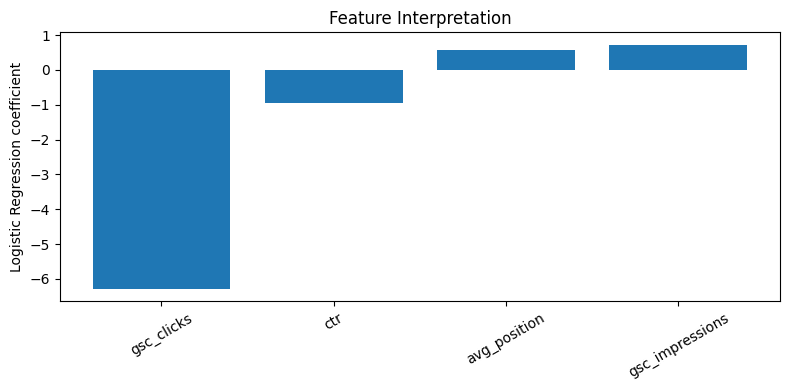

In [17]:
import matplotlib.pyplot as plt

plot_df = feature_importance.sort_values(
    "coefficient"
)

plt.figure(figsize=(8, 4))

plt.bar(
    plot_df["feature"],
    plot_df["coefficient"]
)

plt.xticks(rotation=30)
plt.ylabel("Logistic Regression coefficient")
plt.title("Feature Interpretation")

plt.tight_layout()

plt.savefig(
    "feature_interpretation.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.9846
Precision: 0.9823200992555832
Recall   : 0.9702818627450981
F1 Score : 0.9762638717632552
ROC-AUC  : 0.9991142895140538


Confusion Matrix:
[[13358   114]
 [  194  6334]]


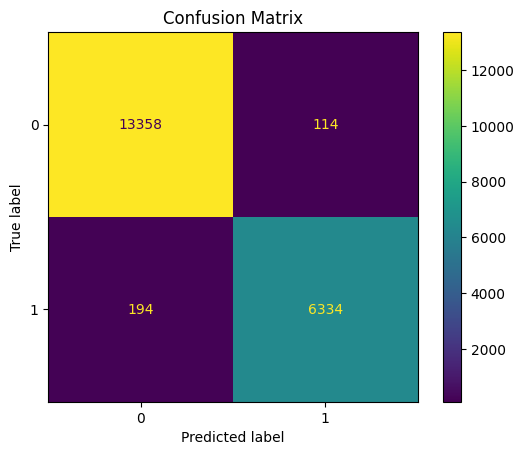

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "feature": features,
    "coefficient": model.coef_[0]
})

# Sort by absolute importance
feature_importance["abs_coefficient"] = (
    feature_importance["coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    by="abs_coefficient",
    ascending=False
)

feature_importance

,feature,coefficient,abs_coefficient
1,gsc_clicks,-6.291374,6.291374
2,ctr,-0.957910,0.957910
0,gsc_impressions,0.729286,0.729286
3,avg_position,0.565170,0.565170


In [21]:
# Create error analysis dataframe

error_analysis = X_test.copy()

error_analysis["actual"] = y_test.values
error_analysis["predicted"] = y_pred

error_analysis["prediction_correct"] = (
    error_analysis["actual"] == error_analysis["predicted"]
)

# Get incorrect predictions
errors = error_analysis[
    error_analysis["prediction_correct"] == False
]

print("Total test samples:", len(error_analysis))
print("Incorrect predictions:", len(errors))
print("Error rate:", len(errors) / len(error_analysis))

errors.head(20)

Total test samples: 20000
Incorrect predictions: 308
Error rate: 0.0154


,gsc_impressions,gsc_clicks,ctr,avg_position,actual,predicted,prediction_correct
9179,10,0,0.0,1.500000,0,1,False
61584,3,0,0.0,9.000000,1,0,False
16473,11,0,0.0,1.545455,0,1,False
17557,3,0,0.0,7.666667,1,0,False
60253,6,0,0.0,4.166667,1,0,False
64805,10,0,0.0,0.800000,0,1,False
62198,4,0,0.0,5.250000,1,0,False
64908,11,0,0.0,1.545455,0,1,False
36181,12,0,0.0,1.250000,0,1,False
61081,2,0,0.0,10.500000,1,0,False


In [22]:
false_positives = error_analysis[
    (error_analysis["actual"] == 0) &
    (error_analysis["predicted"] == 1)
]

false_negatives = error_analysis[
    (error_analysis["actual"] == 1) &
    (error_analysis["predicted"] == 0)
]

print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))

False Positives: 114
False Negatives: 194


In [23]:
print("\nFalse Positive examples:")
display(false_positives.head(10))

print("\nFalse Negative examples:")
display(false_negatives.head(10))


False Positive examples:


,gsc_impressions,gsc_clicks,ctr,avg_position,actual,predicted,prediction_correct
9179,10,0,0.0,1.500000,0,1,False
16473,11,0,0.0,1.545455,0,1,False
64805,10,0,0.0,0.800000,0,1,False
64908,11,0,0.0,1.545455,0,1,False
36181,12,0,0.0,1.250000,0,1,False
53277,1,0,0.0,17.000000,0,1,False
84277,1,0,0.0,14.000000,0,1,False
3005,9,0,0.0,2.000000,0,1,False
56720,1,0,0.0,19.000000,0,1,False
8698,13,0,0.0,0.461538,0,1,False



False Negative examples:


,gsc_impressions,gsc_clicks,ctr,avg_position,actual,predicted,prediction_correct
61584,3,0,0.0,9.000000,1,0,False
17557,3,0,0.0,7.666667,1,0,False
60253,6,0,0.0,4.166667,1,0,False
62198,4,0,0.0,5.250000,1,0,False
61081,2,0,0.0,10.500000,1,0,False
99975,4,0,0.0,5.750000,1,0,False
38992,4,0,0.0,6.000000,1,0,False
6171,7,0,0.0,3.142857,1,0,False
15056,4,0,0.0,5.500000,1,0,False
60487,3,0,0.0,7.000000,1,0,False


In [24]:
# Compare feature averages by actual class

comparison = X_test.copy()

comparison["target"] = y_test.values

class_summary = comparison.groupby("target")[features].mean()

class_summary

,gsc_impressions,gsc_clicks,ctr,avg_position
target,,,,
0,0.357185,0.004305,0.001099,0.425887
1,108.054381,0.322917,0.002280,14.535996


In [25]:
# Get probability of refresh recommendation
priority_df = X_test.copy()

priority_df["actual"] = y_test.values
priority_df["predicted"] = y_pred
priority_df["refresh_probability"] = y_prob

# Sort pages by refresh probability
priority_df = priority_df.sort_values(
    by="refresh_probability",
    ascending=False
)

priority_df.head(20)

,gsc_impressions,gsc_clicks,ctr,avg_position,actual,predicted,refresh_probability
8601,57,0,0.000000,4.982456,1,1,1.0
39352,80,0,0.000000,5.350000,1,1,1.0
35000,690,1,0.001449,6.213043,1,1,1.0
4337,72,0,0.000000,7.472222,1,1,1.0
92174,43,0,0.000000,31.046512,1,1,1.0
3247,64,0,0.000000,6.812500,1,1,1.0
88631,161,0,0.000000,8.279503,1,1,1.0
7527,103,1,0.009709,3.155340,1,1,1.0
93416,125,1,0.008000,28.184000,1,1,1.0
95342,59,0,0.000000,23.932203,1,1,1.0


In [26]:
priority_df["priority"] = pd.cut(
    priority_df["refresh_probability"],
    bins=[0, 0.30, 0.70, 1.0],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

priority_df["priority"].value_counts().sort_index()

,count
priority,
Low,13352
Medium,342
High,6306


In [27]:
priority_summary = priority_df.groupby("priority", observed=False).agg(
    pages=("actual", "count"),
    actual_refresh_rate=("actual", "mean"),
    avg_refresh_probability=("refresh_probability", "mean")
)

priority_summary

,pages,actual_refresh_rate,avg_refresh_probability
priority,,,
Low,13352,0.006141,0.008309
Medium,342,0.625731,0.484040
High,6306,0.988265,0.991139


In [28]:
# Business impact of priority ranking

total_actual_refresh = priority_df["actual"].sum()

high_priority = priority_df[
    priority_df["priority"] == "High"
]

high_priority_actual_refresh = high_priority["actual"].sum()

capture_rate = (
    high_priority_actual_refresh / total_actual_refresh
)

print("Total actual refresh pages:", total_actual_refresh)
print("High-priority pages:", len(high_priority))
print("Actual refresh pages in High priority:", high_priority_actual_refresh)
print("High-priority capture rate:", capture_rate)

Total actual refresh pages: 6528
High-priority pages: 6306
Actual refresh pages in High priority: 6232
High-priority capture rate: 0.9546568627450981


In [29]:
priority_df.to_csv(
    "refresh_priority_results.csv",
    index=False
)

print("Saved: refresh_priority_results.csv")

Saved: refresh_priority_results.csv


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
